In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from dtw import dtw
import copy

from keras.models import Sequential
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, RepeatVector, TimeDistributed, Dropout

import plotly.express as px

In [2]:
from scipy.spatial.distance import cdist

In [3]:
machines= ['SL40309_015']
programs= ['O0005(5303-005-C)']
crs= ['CR1_to_CR4', 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']
base_name = 'data'
paths = []

# data_SL40309_015_O0005(5303-005-C)_CR12_to_CR16

for machine in machines:
    for program in programs:
        for cr in crs:
            path = f'{base_name}_{machine}_{program}_{cr}.csv'
            paths.append(path)
print(paths)

dfs = []

for path in paths:
    data = pd.read_csv(f'../data/{path}')
    dfs.append(data)
    # print(len(data))
    
data = pd.concat(dfs, ignore_index=True)

data = data.pivot(index=['custom_id', 'timestamp', 'status', 'cr'], columns=['name', 'workstationcomponent'], values='value')
data = data.reset_index()
data.columns = [f'{col}_{comp}' if comp != '' else col for col, comp in data.columns]
data.columns

['data_SL40309_015_O0005(5303-005-C)_CR1_to_CR4.csv', 'data_SL40309_015_O0005(5303-005-C)_CR5_to_CR8.csv', 'data_SL40309_015_O0005(5303-005-C)_CR9_to_CR12.csv', 'data_SL40309_015_O0005(5303-005-C)_CR12_to_CR16.csv']


Index(['custom_id', 'timestamp', 'status', 'cr', 'gcode.ncode_Path_Path_1',
       'position_Linear_Z', 'toolnumber_Path_Path_1', 'position_Linear_X',
       'gcode.toolSlotId_Path_Path_1', 'programcomment_Path_Path_1',
       'pathfeedrate_Path_Path_1', 'gcode.program_Path_Path_1',
       'gcode.mcode_Path_Path_1', 'execution_Path_Path_1',
       'spindlespeed_actual_Rotary_C5', 'load_Rotary_C5',
       'spindlerotating_Rotary_C5', 'load_Linear_X',
       'gcode.gearselect_Path_Path_1', 'counter.last30seventscount_nan',
       'gcode.coolant_Path_Path_1', 'coolant_Coolant_Coolant', 'load_Linear_Z',
       'rapidoverride_Path_Path_1', 'controllermode_Path_Path_1',
       'operationmode_Path_Path_1', 'cutting_Path_Path_1', 'heartbeat_datatap',
       'line_Path_Path_1', 'partcount_Path_Path_1',
       'gcode.programname_Path_Path_1', 'fault_Path_Path_1',
       'gcode.spindle_Path_Path_1', 'jogoverride_Path_Path_1'],
      dtype='object')

In [4]:
split_columns = data['status'].str.split('/', expand=True)
data[['program_name', 'nsequence', 'execution']] = split_columns[[0,1,2]]

data['load_Rotary_C5'] = data['load_Rotary_C5'].astype(float)
data['position_Linear_Z'] = data['position_Linear_Z'].astype(float)
data['position_Linear_X'] = data['position_Linear_X'].astype(float)
data['spindlespeed_actual_Rotary_C5'] = data['spindlespeed_actual_Rotary_C5'].astype(float)
data['pathfeedrate_Path_Path_1'] = data['pathfeedrate_Path_Path_1'].astype(float)

data = data.ffill()

In [5]:
# datapoints where machining == True
data = data[data['timestamp'] <'2024-04-12']
data = data[(data['execution'] == 'ACTIVE') & 
            (data['spindlespeed_actual_Rotary_C5'] != 0) & 
            (data['pathfeedrate_Path_Path_1'] != 0) & 
            (data['load_Rotary_C5'] > 0) & 
            (data['pathfeedrate_Path_Path_1'] <= 1000)]

In [6]:
len(data)

85606

In [7]:
data.tail(5)

,custom_id,timestamp,status,cr,gcode.ncode_Path_Path_1,position_Linear_Z,toolnumber_Path_Path_1,position_Linear_X,gcode.toolSlotId_Path_Path_1,programcomment_Path_Path_1,...,heartbeat_datatap,line_Path_Path_1,partcount_Path_Path_1,gcode.programname_Path_Path_1,fault_Path_Path_1,gcode.spindle_Path_Path_1,jogoverride_Path_Path_1,program_name,nsequence,execution
119737,20097830,2024-03-12 06:39:53.838287,O0005(5303-005-C)/N40/ACTIVE,CR-16,N40G04X2000,14.1226,1212,19.1076,G0T1212,ROUGH OD ONLY,...,1709247815674,10,886,O0005(5303-005-C),OVER TRAVEL : -,stop,90,O0005(5303-005-C),N40,ACTIVE
119738,20097831,2024-03-12 06:39:53.838287,O0005(5303-005-C)/N40/ACTIVE,CR-16,N40G04X2000,14.1226,1212,-0.0885,G0T1212,ROUGH OD ONLY,...,1709247815674,10,886,O0005(5303-005-C),OVER TRAVEL : -,stop,90,O0005(5303-005-C),N40,ACTIVE
119739,20097832,2024-03-12 06:39:53.838287,O0005(5303-005-C)/N40/ACTIVE,CR-16,N40G04X2000,14.1226,1212,-0.0885,G0T1212,ROUGH OD ONLY,...,1709247815674,10,886,O0005(5303-005-C),OVER TRAVEL : -,stop,90,O0005(5303-005-C),N40,ACTIVE
119740,20097833,2024-03-12 06:39:53.838287,O0005(5303-005-C)/N40/ACTIVE,CR-16,N40G04X2000,-5.6411,1212,-0.0885,G0T1212,ROUGH OD ONLY,...,1709247815674,10,886,O0005(5303-005-C),OVER TRAVEL : -,stop,90,O0005(5303-005-C),N40,ACTIVE
119741,20097834,2024-03-12 06:39:53.838287,O0005(5303-005-C)/N40/ACTIVE,CR-16,N40G04X2000,-5.6411,1212,-0.0885,G0T1212,ROUGH OD ONLY,...,1709247815674,10,886,O0005(5303-005-C),OVER TRAVEL : -,stop,90,O0005(5303-005-C),N40,ACTIVE


In [8]:

dfN10_load = data[['timestamp', 'load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution', 'program_name', 'nsequence', 'cr']]

In [9]:
len(dfN10_load)

85606

In [10]:
dfN10_load = dfN10_load.drop_duplicates(subset=['timestamp'], keep ='first')
dfN10_load.reset_index(drop=True)
len(dfN10_load)

9937

In [11]:
dfN10_load['index'] = dfN10_load.groupby(['cr']).cumcount()

In [12]:
fig = px.line(dfN10_load, x="index", y="load_Rotary_C5", color='cr')
fig.update_layout(title_text="Load Vs Index")
fig.show()

In [13]:
LE = LabelEncoder()

dfN10_load['execution'] = LE.fit_transform(dfN10_load['execution'])
dfN10_load.fillna(0, inplace=True)

In [14]:
scaler1 = MinMaxScaler()

dfN10_load[['load_Rotary_C5_temp']] = scaler1.fit_transform(dfN10_load[['load_Rotary_C5']])

In [15]:
dfN10_load.head()

,timestamp,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1,execution,program_name,nsequence,cr,index,load_Rotary_C5_temp
46,2024-03-11 14:01:19.408233,2.0,18.8794,12.5102,35.0,238.02,0,O0005(5303-005-C),N10,CR-1,0,0.014493
49,2024-03-11 14:01:29.432814,2.0,18.8794,12.5102,31.0,238.02,0,O0005(5303-005-C),N10,CR-1,1,0.014493
63,2024-03-11 14:01:37.451878,1.0,16.9492,4.7948,34.0,238.02,0,O0005(5303-005-C),N10,CR-1,2,0.000000
64,2024-03-11 14:01:44.468672,1.0,16.9492,4.7948,33.0,238.02,0,O0005(5303-005-C),N10,CR-1,3,0.000000
78,2024-03-11 14:01:52.489886,1.0,16.5496,3.1977,34.0,14.81,0,O0005(5303-005-C),N10,CR-1,4,0.000000


In [16]:
dfN10_load['cr'].value_counts()

cr
CR-1     783
CR-10    778
CR-13    744
CR-4     740
CR-2     665
CR-3     664
CR-11    655
CR-12    654
CR-8     538
CR-14    537
CR-5     535
CR-6     531
CR-7     531
CR-9     530
CR-16    529
CR-15    523
Name: count, dtype: int64

In [17]:
dfN10_load['nsequence'].value_counts()

nsequence
N20    3729
N30    3205
N10    2477
N40     526
Name: count, dtype: int64

In [18]:
def euclidean_distance(x, y):
    return abs(x - y)  

def dtw_cost_alignment(df):
    size = len(df['cr'].value_counts())
    dtw_costs = [[0 for _ in range(size)] for _ in range(size)]
    for i in range(size):
        for j in range(i, size):
            df_load_template = df.loc[df['cr'] == f'CR-{i+1}', 'load_Rotary_C5_temp'].values
            df_load_template = df_load_template[~np.isnan(df_load_template)]

            df_load_query = df.loc[df['cr'] == f'CR-{j+1}', 'load_Rotary_C5_temp'].values
            df_load_query = df_load_query[~np.isnan(df_load_query)]

            dtw_cost = dtw(df_load_template, df_load_query,dist=euclidean_distance)
            # dist_matrix = cdist(df_load_template, df_load_query, metric='euclidean')
            # dtw_cost = dtw(dist_matrix, keep_internals=False)
            
            cost = round(dtw_cost[0],5)
            print(f'CR: {i+1}-{j+1} COST: {cost}')
            dtw_costs[i][j] = cost
            dtw_costs[j][i] = cost
    return dtw_costs


In [19]:
def cost_per_time_stamp(df, cost):
    costs_size = len(df['cr'].value_counts())
    new_costs = [[0 for _ in range(costs_size)] for _ in range(costs_size)]
    for i in range(costs_size):
        for j in range(i, costs_size):
            df_load_query = df.loc[df['cr'] == f'CR-{j+1}', 'load_Rotary_C5_temp'].values
            df_load_query = df_load_query[~np.isnan(df_load_query)]

            size = len(df_load_query)
            new_cost = round(cost[i][j]/size, 5)
            
            new_costs[i][j] = new_cost
            new_costs[j][i] = new_cost
            
    return new_costs
    

In [20]:
n10_dtw_cost = dtw_cost_alignment(dfN10_load)


CR: 1-1 COST: 0.0
CR: 1-2 COST: 35.98551
CR: 1-3 COST: 41.07246
CR: 1-4 COST: 37.43478
CR: 1-5 COST: 32.2029
CR: 1-6 COST: 40.2029
CR: 1-7 COST: 28.97101
CR: 1-8 COST: 38.27536
CR: 1-9 COST: 34.75362
CR: 1-10 COST: 1.05797
CR: 1-11 COST: 33.6087
CR: 1-12 COST: 40.71014
CR: 1-13 COST: 37.42029
CR: 1-14 COST: 32.78261
CR: 1-15 COST: 38.91304
CR: 1-16 COST: 28.72464
CR: 2-2 COST: 0.0
CR: 2-3 COST: 15.10145
CR: 2-4 COST: 19.26087
CR: 2-5 COST: 13.81159
CR: 2-6 COST: 14.7971
CR: 2-7 COST: 13.88406
CR: 2-8 COST: 13.26087
CR: 2-9 COST: 17.04348
CR: 2-10 COST: 36.88406
CR: 2-11 COST: 2.65217
CR: 2-12 COST: 14.6087
CR: 2-13 COST: 18.86957
CR: 2-14 COST: 14.5942
CR: 2-15 COST: 14.2029
CR: 2-16 COST: 14.2029
CR: 3-3 COST: 0.0
CR: 3-4 COST: 19.44928
CR: 3-5 COST: 17.04348
CR: 3-6 COST: 11.71014
CR: 3-7 COST: 18.15942
CR: 3-8 COST: 13.5942
CR: 3-9 COST: 16.31884
CR: 3-10 COST: 41.52174
CR: 3-11 COST: 15.69565
CR: 3-12 COST: 0.46377
CR: 3-13 COST: 18.85507
CR: 3-14 COST: 18.14493
CR: 3-15 COST: 11.7

In [21]:
print(n10_dtw_cost)

[[0.0, 35.98551, 41.07246, 37.43478, 32.2029, 40.2029, 28.97101, 38.27536, 34.75362, 1.05797, 33.6087, 40.71014, 37.42029, 32.78261, 38.91304, 28.72464], [35.98551, 0.0, 15.10145, 19.26087, 13.81159, 14.7971, 13.88406, 13.26087, 17.04348, 36.88406, 2.65217, 14.6087, 18.86957, 14.5942, 14.2029, 14.2029], [41.07246, 15.10145, 0.0, 19.44928, 17.04348, 11.71014, 18.15942, 13.5942, 16.31884, 41.52174, 15.69565, 0.46377, 18.85507, 18.14493, 11.76812, 17.95652], [37.43478, 19.26087, 19.44928, 0.0, 12.23188, 13.43478, 16.46377, 15.52174, 12.04348, 38.43478, 16.95652, 18.7971, 0.78261, 12.81159, 12.5942, 16.18841], [32.2029, 13.81159, 17.04348, 12.23188, 0.0, 10.82609, 12.13043, 12.49275, 9.44928, 33.15942, 12.98551, 16.3913, 12.86957, 1.42029, 10.13043, 11.86957], [40.2029, 14.7971, 11.71014, 13.43478, 10.82609, 0.0, 12.65217, 11.07246, 9.23188, 39.71014, 14.30435, 11.24638, 12.72464, 12.24638, 0.82609, 12.50725], [28.97101, 13.88406, 18.15942, 16.46377, 12.13043, 12.65217, 0.0, 10.7971, 12.62

In [22]:
# n10_dtw_cost = [[0.0, 35.98551, 41.07246, 37.43478, 32.2029, 40.2029, 28.97101, 38.27536, 34.75362, 1.05797, 33.6087, 40.71014, 37.42029, 32.78261, 38.91304, 28.72464], [35.98551, 0.0, 15.10145, 19.26087, 13.81159, 14.7971, 13.88406, 13.26087, 17.04348, 36.88406, 2.65217, 14.6087, 18.86957, 14.5942, 14.2029, 14.2029], [41.07246, 15.10145, 0.0, 19.44928, 17.04348, 11.71014, 18.15942, 13.5942, 16.31884, 41.52174, 15.69565, 0.46377, 18.85507, 18.14493, 11.76812, 17.95652], [37.43478, 19.26087, 19.44928, 0.0, 12.23188, 13.43478, 16.46377, 15.52174, 12.04348, 38.43478, 16.95652, 18.7971, 0.78261, 12.81159, 12.5942, 16.18841], [32.2029, 13.81159, 17.04348, 12.23188, 0.0, 10.82609, 12.13043, 12.49275, 9.44928, 33.15942, 12.98551, 16.3913, 12.86957, 1.42029, 10.13043, 11.86957], [40.2029, 14.7971, 11.71014, 13.43478, 10.82609, 0.0, 12.65217, 11.07246, 9.23188, 39.71014, 14.30435, 11.24638, 12.72464, 12.24638, 0.82609, 12.50725], [28.97101, 13.88406, 18.15942, 16.46377, 12.13043, 12.65217, 0.0, 10.7971, 12.62319, 29.81159, 12.46377, 17.72464, 16.55072, 12.71014, 12.43478, 0.31884], [38.27536, 13.26087, 13.5942, 15.52174, 12.49275, 11.07246, 10.7971, 0.0, 10.81159, 39.11594, 13.23188, 13.0, 15.31884, 12.43478, 10.71014, 10.73913], [34.75362, 17.04348, 16.31884, 12.04348, 9.44928, 9.23188, 12.62319, 10.81159, 0.0, 35.66667, 14.50725, 15.7971, 12.55072, 10.02899, 8.46377, 12.18841], [1.05797, 36.88406, 41.52174, 38.43478, 33.15942, 39.71014, 29.81159, 39.11594, 35.66667, 0.0, 34.50725, 41.17391, 38.42029, 33.6087, 38.88406, 29.56522], [33.6087, 2.65217, 15.69565, 16.95652, 12.98551, 14.30435, 12.46377, 13.23188, 14.50725, 34.50725, 0.0, 15.2029, 16.71014, 13.56522, 13.71014, 12.13043], [40.71014, 14.6087, 0.46377, 18.7971, 16.3913, 11.24638, 17.72464, 13.0, 15.7971, 41.17391, 15.2029, 0.0, 18.2029, 17.49275, 11.24638, 17.4058], [37.42029, 18.86957, 18.85507, 0.78261, 12.86957, 12.72464, 16.55072, 15.31884, 12.55072, 38.42029, 16.71014, 18.2029, 0.0, 13.44928, 12.86957, 16.26087], [32.78261, 14.5942, 18.14493, 12.81159, 1.42029, 12.24638, 12.71014, 12.43478, 10.02899, 33.6087, 13.56522, 17.49275, 13.44928, 0.0, 11.55072, 12.44928], [38.91304, 14.2029, 11.76812, 12.5942, 10.13043, 0.82609, 12.43478, 10.71014, 8.46377, 38.88406, 13.71014, 11.24638, 12.86957, 11.55072, 0.0, 12.11594], [28.72464, 14.2029, 17.95652, 16.18841, 11.86957, 12.50725, 0.31884, 10.73913, 12.18841, 29.56522, 12.13043, 17.4058, 16.26087, 12.44928, 12.11594, 0.0]]

In [23]:
n10_dtw_cost_per_timestamp = cost_per_time_stamp(dfN10_load, n10_dtw_cost)

In [24]:
print(n10_dtw_cost_per_timestamp)

[[0.0, 0.05411, 0.06186, 0.05059, 0.06019, 0.07571, 0.05456, 0.07114, 0.06557, 0.00136, 0.05131, 0.06225, 0.0503, 0.06105, 0.0744, 0.0543], [0.05411, 0.0, 0.02274, 0.02603, 0.02582, 0.02787, 0.02615, 0.02465, 0.03216, 0.04741, 0.00405, 0.02234, 0.02536, 0.02718, 0.02716, 0.02685], [0.06186, 0.02274, 0.0, 0.02628, 0.03186, 0.02205, 0.0342, 0.02527, 0.03079, 0.05337, 0.02396, 0.00071, 0.02534, 0.03379, 0.0225, 0.03394], [0.05059, 0.02603, 0.02628, 0.0, 0.02286, 0.0253, 0.03101, 0.02885, 0.02272, 0.0494, 0.02589, 0.02874, 0.00105, 0.02386, 0.02408, 0.0306], [0.06019, 0.02582, 0.03186, 0.02286, 0.0, 0.02039, 0.02284, 0.02322, 0.01783, 0.04262, 0.01983, 0.02506, 0.0173, 0.00264, 0.01937, 0.02244], [0.07571, 0.02787, 0.02205, 0.0253, 0.02039, 0.0, 0.02383, 0.02058, 0.01742, 0.05104, 0.02184, 0.0172, 0.0171, 0.02281, 0.00158, 0.02364], [0.05456, 0.02615, 0.0342, 0.03101, 0.02284, 0.02383, 0.0, 0.02007, 0.02382, 0.03832, 0.01903, 0.0271, 0.02225, 0.02367, 0.02378, 0.0006], [0.07114, 0.02465, 0

In [25]:
def compute_percentile(values, percentile_k):
    """
    Compute the percentile value using linear interpolation.
    
    Parameters:
    -----------
    values : list or array of numeric values
    percentile_k : float, percentile level (0-100)
    
    Returns:
    --------
    float : the percentile value
    """
    sorted_values = sorted(values)
    N = len(sorted_values)
    
    if N == 0:
        return 0
    
    # Compute position using (percentile_k / 100) * (N - 1)
    position = (percentile_k / 100) * (N - 1)
    lower_index = int(np.floor(position))
    upper_index = int(np.ceil(position))
    
    if lower_index == upper_index:
        return sorted_values[lower_index]
    
    # Linear interpolation between lower and upper values
    fraction = position - lower_index
    lower_value = sorted_values[lower_index]
    upper_value = sorted_values[upper_index]
    
    percentile_value = lower_value + fraction * (upper_value - lower_value)
    
    return percentile_value


def get_crs_using_dynamic_threshold(normalized_cost, n_crs, k):
    """
    Identify valid CRs using statistical dynamic thresholding based on IQR method.
    
    Parameters:
    -----------
    normalized_cost : 2D list or array (N x N)
        Symmetric matrix of normalized DTW costs where N = n_crs
        Index i (0-based in matrix) corresponds to CR-(i+1) (1-based CR number)
    
    n_crs : int
        Number of unique CRs (e.g., 16)
    
    k : float, 
        Multiplier for IQR in threshold calculation: threshold = Q3 + (k * IQR)
    
    Returns:
    --------
    inlier_crs : set of int
        CR numbers (1-indexed: 1 to n_crs) that are valid (within threshold)
    
    outlier_crs : set of int
        CR numbers (1-indexed: 1 to n_crs) that are outliers (exceed threshold)
    
    dynamic_threshold : float
        The computed threshold value
    
    mean_distances : list of float
        Mean normalized DTW distance for each CR (for debugging/visualization)
        Index i corresponds to CR-(i+1)
    """
    
    # Step 1: Compute mean normalized DTW distance per CR
    mean_distances = []
    
    for i in range(n_crs):
        sum_cost = 0
        count = 0
        
        # Sum costs from all other CRs (exclude self, where i == j)
        for j in range(n_crs):
            if i != j:
                sum_cost += normalized_cost[i][j]
                count += 1
        
        # Compute mean distance (denominator is N-1, excluding self-distance)
        if count > 0:
            mean_value = sum_cost / count
        else:
            mean_value = 0
        
        mean_distances.append(mean_value)
    
    # Step 2: Compute dynamic threshold using quartile-based IQR method
    Q1 = compute_percentile(mean_distances, 25)
    Q3 = compute_percentile(mean_distances, 75)
    IQR = Q3 - Q1
    dynamic_threshold = Q3 + (k * IQR)
    
    # Step 3: Classify CRs as inliers or outliers
    inlier_crs = set()
    outlier_crs = set()
    
    for i in range(n_crs):
        cr_number = i + 1  # Convert 0-indexed matrix to 1-indexed CR number
        if mean_distances[i] <= dynamic_threshold:
            inlier_crs.add(cr_number)
        else:
            outlier_crs.add(cr_number)
    
    return inlier_crs, outlier_crs, dynamic_threshold, mean_distances


In [26]:
def display_crs(costs, df, k):
    """
    Display CRs that pass dynamic threshold filtering and visualize their load profiles.
    
    Parameters:
    -----------
    costs : 2D list or array (N x N)
        Normalized DTW cost matrix
    
    df : pandas DataFrame
        Data containing CR information with 'cr' column
    
    k : float,
        Multiplier for IQR in threshold calculation
    
    Returns:
    --------
    cr_set : set of int
        CR numbers (1-indexed) that passed the threshold filter
    
    filtered_df : pandas DataFrame
        Filtered dataframe containing only rows from valid CRs
    """
    
    # Get number of CRs from cost matrix
    n_crs = len(costs)
    
    # Compute inlier and outlier CRs using dynamic threshold
    inlier_crs, outlier_crs, dyn_threshold, mean_distances = get_crs_using_dynamic_threshold(costs, n_crs, k)
    
    
    # Print statistics
    print(f'Dynamic Threshold (k={k}): {dyn_threshold:.5f}')
    # print(f'Q1: {Q1:.5f}, Q3: {Q3:.5f}, IQR: {IQR:.5f}')
    print(f'Number of valid CRs: {len(inlier_crs)}')
    print(f'Number of outlier CRs: {len(outlier_crs)}')
    
    if outlier_crs:
        outlier_names = sorted([f'CR-{i}' for i in outlier_crs])
        print(f'Outlier CRs: {outlier_names}')
    
    print(f'Mean distances per CR (index i = CR-(i+1)): {[round(m, 5) for m in mean_distances]}')
    
    # Extract CR numeric values and filter
    df = df.copy()
    df['cr_numeric'] = df['cr'].str.extract(r'(\d+)')
    df['cr_numeric'] = pd.to_numeric(df['cr_numeric'])
    
    filtered_df = df[df['cr_numeric'].isin(inlier_crs)]
    filtered_df = filtered_df.reset_index(drop=True)
    filtered_df['index'] = filtered_df.groupby(['cr_numeric']).cumcount()
    
    # Visualize
    fig = px.line(filtered_df, x="index", y="load_Rotary_C5_temp", color='cr')
    fig.update_layout(title_text="Load Vs Index (Valid CRs Only)")
    fig.show()
    
    return inlier_crs, filtered_df


In [27]:
# Nsequence: N10
# Dynamic threshold with k (tunable parameter)
df10_cr_set, dfN10_load_filtered_cr = display_crs(n10_dtw_cost_per_timestamp, dfN10_load, k=0.05)

Dynamic Threshold (k=0.05): 0.02850
Number of valid CRs: 12
Number of outlier CRs: 4
Outlier CRs: ['CR-1', 'CR-10', 'CR-14', 'CR-3']
Mean distances per CR (index i = CR-(i+1)): [0.05658, 0.02799, 0.02991, 0.02782, 0.02495, 0.02589, 0.02608, 0.02727, 0.02651, 0.04932, 0.0254, 0.02834, 0.02501, 0.02853, 0.02808, 0.02831]


In [28]:
df10_cr_set = list(df10_cr_set)
size = len(df10_cr_set)

train_ratio = 0.8
train_size = int(size*train_ratio)
test_size = size - train_size

print('train_size: ', train_size)
print('test_size: ', test_size)

train_crs = df10_cr_set[0: train_size]
test_crs = df10_cr_set[train_size: -1]

print('train_crs: ', train_crs)
print('test_crs: ', test_crs)

train_size:  9
test_size:  3
train_crs:  [2, 4, 5, 6, 7, 8, 9, 11, 12]
test_crs:  [13, 15]


In [29]:
def to_sequences(x, seq_size):
    x_values = []
    y_values = []
    for i in range(len(x) - seq_size):
        x_values.append(x[i : (i + seq_size)])
        y_values.append(x[i + seq_size])
    return np.array(x_values), np.array(y_values)

In [30]:
dfN10_train_data = dfN10_load_filtered_cr[dfN10_load_filtered_cr['cr_numeric'].isin(train_crs)]
len(dfN10_train_data)

5379

In [31]:
dfN10_test_data = dfN10_load_filtered_cr[dfN10_load_filtered_cr['cr_numeric'].isin(test_crs)]
len(dfN10_test_data)

1267

In [32]:
dfN10_train_data[['timestamp', 'load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'cr', ]].head(10)

,timestamp,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1,cr
0,2024-03-11 15:40:47.167578,2.0,18.886,10.1493,35.0,239.27,CR-2
1,2024-03-11 15:40:56.190506,1.0,18.886,10.1493,35.0,239.27,CR-2
2,2024-03-11 15:41:01.202792,1.0,16.250,3.9771,35.0,239.25,CR-2
3,2024-03-11 15:42:17.411486,2.0,16.250,0.8980,35.0,10.78,CR-2
4,2024-03-11 15:42:22.424109,1.0,16.250,0.8980,35.0,10.78,CR-2
5,2024-03-11 15:42:27.436144,1.0,16.250,0.3716,35.0,15.70,CR-2
6,2024-03-11 15:42:31.445722,1.0,16.250,0.3349,35.0,1.41,CR-2
7,2024-03-11 15:42:33.450631,1.0,16.250,0.2983,35.0,1.41,CR-2
8,2024-03-11 15:42:35.454065,1.0,16.250,0.2983,35.0,1.41,CR-2
9,2024-03-11 15:42:37.459369,1.0,16.250,0.2615,34.0,1.41,CR-2


In [33]:
dfN10_train_data = dfN10_train_data[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', ]]
dfN10_test_data = dfN10_test_data[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', ]]

In [34]:
dfN10_train_data.head(10)

,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1
0,2.0,18.886,10.1493,35.0,239.27
1,1.0,18.886,10.1493,35.0,239.27
2,1.0,16.250,3.9771,35.0,239.25
3,2.0,16.250,0.8980,35.0,10.78
4,1.0,16.250,0.8980,35.0,10.78
5,1.0,16.250,0.3716,35.0,15.70
6,1.0,16.250,0.3349,35.0,1.41
7,1.0,16.250,0.2983,35.0,1.41
8,1.0,16.250,0.2983,35.0,1.41
9,1.0,16.250,0.2615,34.0,1.41


In [35]:
scaler2 = MinMaxScaler()
data_scaled = scaler2.fit(dfN10_train_data)
# Scaling dataset according to weights of train data
dfN10_train_data_scaled = data_scaled.transform(dfN10_train_data)
dfN10_test_data_scaled = data_scaled.transform(dfN10_test_data)

In [36]:
type(dfN10_train_data_scaled)

numpy.ndarray

In [37]:
temp_df = pd.DataFrame(dfN10_train_data_scaled, columns=['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1'])
temp_df.head()

,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1
0,0.019608,0.951336,0.725622,0.052632,0.992815
1,0.000000,0.951336,0.725622,0.052632,0.992815
2,0.000000,0.819174,0.441988,0.052632,0.992732
3,0.019608,0.819174,0.300494,0.052632,0.043818
4,0.000000,0.819174,0.300494,0.052632,0.043818


In [38]:
temp_df.to_csv("D:/baseline_improvement-main/src/training_data.csv", index=False)

In [39]:
del temp_df

In [40]:
dfN10_train_data_scaled[:10]

array([[0.01960784, 0.95133642, 0.72562175, 0.05263158, 0.99281472],
       [0.        , 0.95133642, 0.72562175, 0.05263158, 0.99281472],
       [0.        , 0.81917363, 0.44198849, 0.05263158, 0.99273165],
       [0.01960784, 0.81917363, 0.30049354, 0.05263158, 0.04381775],
       [0.        , 0.81917363, 0.30049354, 0.05263158, 0.04381775],
       [0.        , 0.81917363, 0.2763037 , 0.05263158, 0.06425219],
       [0.        , 0.81917363, 0.27461721, 0.05263158, 0.00490094],
       [0.        , 0.81917363, 0.27293532, 0.05263158, 0.00490094],
       [0.        , 0.81917363, 0.27293532, 0.05263158, 0.00490094],
       [0.        , 0.81917363, 0.27124423, 0.05023923, 0.00490094]])

In [41]:
type(dfN10_train_data_scaled)

numpy.ndarray

In [42]:
df10_trainX, df10_trainY = to_sequences(dfN10_train_data_scaled, 10)
print(df10_trainX.shape, df10_trainY.shape)

df10_testX, df10_testY = to_sequences(dfN10_test_data_scaled, 10)
print(df10_testX.shape, df10_testY.shape)

(5369, 10, 5) (5369, 5)
(1257, 10, 5) (1257, 5)


In [43]:
df10_trainX[:1]

array([[[0.01960784, 0.95133642, 0.72562175, 0.05263158, 0.99281472],
        [0.        , 0.95133642, 0.72562175, 0.05263158, 0.99281472],
        [0.        , 0.81917363, 0.44198849, 0.05263158, 0.99273165],
        [0.01960784, 0.81917363, 0.30049354, 0.05263158, 0.04381775],
        [0.        , 0.81917363, 0.30049354, 0.05263158, 0.04381775],
        [0.        , 0.81917363, 0.2763037 , 0.05263158, 0.06425219],
        [0.        , 0.81917363, 0.27461721, 0.05263158, 0.00490094],
        [0.        , 0.81917363, 0.27293532, 0.05263158, 0.00490094],
        [0.        , 0.81917363, 0.27293532, 0.05263158, 0.00490094],
        [0.        , 0.81917363, 0.27124423, 0.05023923, 0.00490094]]])

In [44]:
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, RepeatVector, Dense, TimeDistributed
from tensorflow.keras.models import Model

class LSTMTimeSeriesAutoencoder:
    def __init__(self, sequence_length, num_dimensions, dim_weights):
        self.sequence_length = sequence_length
        self.num_dimensions = num_dimensions
        self.dim_weights = dim_weights
        self.model = self.build_model()

    def build_model(self):
        # Define input shape
        input_shape = (self.sequence_length, self.num_dimensions)

        # Encoder
        encoder_inputs = Input(shape=input_shape)
        encoder = LSTM(128, return_sequences=True)(encoder_inputs)
        encoder = LSTM(64, return_sequences=True)(encoder)
        encoder = LSTM(32, return_sequences=True)(encoder)
        encoder = LSTM(16, return_sequences=True)(encoder)
        encoder = LSTM(8, return_sequences=False)(encoder)

        # Repeat the latent vector for each time step
        decoder_inputs = RepeatVector(self.sequence_length)(encoder)

        # Decoder
        decoder = LSTM(8, return_sequences=True)(decoder_inputs)
        decoder = LSTM(16, return_sequences=True)(decoder)
        decoder = LSTM(32, return_sequences=True)(decoder)
        decoder = LSTM(64, return_sequences=True)(decoder)
        decoder = LSTM(128, return_sequences=True)(decoder)

        # Output layer
        output = TimeDistributed(Dense(self.num_dimensions))(decoder)

        # Define the model
        model = Model(inputs=encoder_inputs, outputs=output)

        return model

    def custom_loss(self, y_true, y_pred):
        # Define weights for each dimension
        weights = tf.constant(self.dim_weights, dtype=tf.float32)

        # Calculate mean squared error (MSE) for each dimension
        mse = tf.reduce_mean(tf.square(y_true - y_pred), axis=0)

        # Multiply MSE by weights and sum across dimensions
        weighted_loss = tf.reduce_sum(mse * weights)

        return weighted_loss

    def compile_model(self):
        self.model.compile(optimizer='adam', loss=self.custom_loss)

    def summary(self):
        self.model.summary()

    def train(self, x_train, epochs, batch_size, callbacks):
        history = self.model.fit(x_train, x_train, epochs=epochs, batch_size=batch_size, verbose=1, validation_split=0.1,  callbacks=callbacks, shuffle=False)
        return history

    def predict(self, x):
        return self.model.predict(x)

    def save_weights(self, filepath):
        # Save model weights
        self.model.save_weights(filepath)

    def load_weights(self, filepath):
        # Load model weights
        self.model.load_weights(filepath)


In [45]:
from keras.callbacks import ModelCheckpoint

# Define the ModelCheckpoint callback
checkpoint = ModelCheckpoint(filepath='deployment_work/artifacts/latest/models/LSTM_Autoencoder_30_April_2024_program_level.keras', 
                             monitor='val_loss', 
                             verbose=1, 
                             save_best_only=True, 
                             mode='min')

In [46]:
model = LSTMTimeSeriesAutoencoder(sequence_length= df10_trainX.shape[1], num_dimensions=df10_trainX.shape[2], dim_weights = [0.8, 0.05, 0.05, 0.05, 0.025])

In [47]:
print(type(model))

<class '__main__.LSTMTimeSeriesAutoencoder'>


In [48]:
model.compile_model()
# type(model)
history = model.train(x_train=df10_trainX, epochs=50, batch_size=64, callbacks=[checkpoint])


Epoch 1/50

75/76 [============================>.] - ETA: 0s - loss: 0.6123
Epoch 1: val_loss improved from inf to 0.38056, saving model to deployment_work/artifacts/latest/models\LSTM_Autoencoder_30_April_2024_program_level.keras
76/76 [==============================] - 19s 83ms/step - loss: 0.6111 - val_loss: 0.3806
Epoch 2/50
76/76 [==============================] - ETA: 0s - loss: 0.3081
Epoch 2: val_loss improved from 0.38056 to 0.24340, saving model to deployment_work/artifacts/latest/models\LSTM_Autoencoder_30_April_2024_program_level.keras
76/76 [==============================] - 3s 45ms/step - loss: 0.3081 - val_loss: 0.2434
Epoch 3/50
76/76 [==============================] - ETA: 0s - loss: 0.1971
Epoch 3: val_loss improved from 0.24340 to 0.15190, saving model to deployment_work/artifacts/latest/models\LSTM_Autoencoder_30_April_2024_program_level.keras
76/76 [==============================] - 3s 46ms/step - loss: 0.1971 - val_loss: 0.1519
Epoch 4/50
75/76 [=================

In [49]:
model = LSTMTimeSeriesAutoencoder(sequence_length= df10_trainX.shape[1], num_dimensions=df10_trainX.shape[2], dim_weights = [0.8, 0.05, 0.05, 0.05, 0.025])
# Load model weights
model.load_weights('deployment_work/artifacts/latest/models/LSTM_Autoencoder_30_April_2024_program_level.keras')

In [50]:
model.model.to_json()

'{"class_name": "Functional", "config": {"name": "model_1", "trainable": true, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_input_shape": [null, 10, 5], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_2"}, "registered_name": null, "name": "input_2", "inbound_nodes": []}, {"module": "keras.layers", "class_name": "LSTM", "config": {"name": "lstm_10", "trainable": true, "dtype": "float32", "return_sequences": true, "return_state": false, "go_backwards": false, "stateful": false, "unroll": false, "time_major": false, "units": 128, "activation": "tanh", "recurrent_activation": "sigmoid", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "recurrent_initializer": {"module": "keras.initializers", "class_name": "Orthogonal", "config": {"gain": 1.0, "seed": null}, "registered_name": null}, "bias_initializer": {"module": "keras.initi

In [51]:
predicted_load_train = model.predict(df10_trainX)

168/168 [==============================] - 6s 16ms/step


In [52]:
df10_trainX[10:20,4,0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [53]:
predicted_load_train[10:20, 4, 0]

array([-0.00873352, -0.00878334, -0.00883991, -0.00884736, -0.00884772,
       -0.00882804, -0.00880529, -0.01034511, -0.01077618, -0.01162314],
      dtype=float32)

In [54]:
def get_mean_and_std(x,y,t):
    error = x[:,t,0] - y[:, t, 0]
    mean_rmse = np.sqrt(np.mean(np.square(error)))
    std_rmse = np.std(error)
    return mean_rmse, std_rmse
    

In [55]:
def mark_anomaly(x, y, t, mean, std, relax=1):
    error = x[:,t,0] - y[:, t, 0]
    deviation = np.abs(error)

    threshold = mean + relax*std
    anomalies = deviation > threshold

    # print(mean_rmse, std_rmse, error, deviation)
    # print(anomalies)
    return anomalies

In [56]:
mean, std =  get_mean_and_std(df10_trainX, predicted_load_train, 4)
print(mean, std)

0.048996120459861674 0.04899224523001596


In [57]:
anomaly = mark_anomaly(df10_trainX, predicted_load_train, 4, mean, std)

In [58]:
# Model conversion to ONNX: 
# !pip install tf2onnx onnxruntime --quiet

In [59]:
def display_prediction(df10_trainX, predicted_load_train, t, mean, std, relax):
    
    anomaly=mark_anomaly(df10_trainX, predicted_load_train, t, mean, std, relax)
    # print()
    # Create DataFrames for actual and predicted values
    # print(anomaly)
    df1 = pd.DataFrame({'x': range(len(df10_trainX)), 'y': df10_trainX[:, t, 0], 'color': 'Actual', 'anomaly': anomaly})
    df2 = pd.DataFrame({'x': range(len(predicted_load_train)), 'y': predicted_load_train[:, t, 0], 'color': 'Predicted', 'anomaly': False})
    # df3 = pd.DataFrame({'x': range(len(predicted_load_train)), 'y': predicted_load_train[:, t, 0], 'color': 'Anomaly', 'anomaly':anomaly})
    
    # Concatenate the DataFrames
    df = pd.concat([df1, df2])
    # print(df)
    # Plot both actual and predicted values
    fig = px.line(df, x='x', y='y', color='color')

    df_anomaly = df[df['anomaly']==True]
    print("Number of anomalies: ", len(df_anomaly))
    scatter_data = px.scatter(df_anomaly, x='x', y='y', color_discrete_sequence=['black']).data[0]
    scatter_data.update(marker=dict(size=5))
    fig.add_trace(scatter_data)

    fig.show()


In [60]:
display_prediction(df10_trainX, predicted_load_train, 4, mean, std, 2)

Number of anomalies:  105


In [61]:
predicted_load_test = model.predict(df10_testX)

40/40 [==============================] - 1s 24ms/step


In [62]:
# results on test data 

In [64]:
display_prediction(df10_testX, predicted_load_test, 4, mean, std, 2)

Number of anomalies:  15


In [64]:
type(df10_trainX)

numpy.ndarray

In [65]:
# # --- Save artifacts for export & inference ---
# import os
# import json
# import pickle

# os.makedirs("deployment_work/artifacts/latest", exist_ok=True)
# ART_DIR = "deployment_work/artifacts/latest"

# # 4) Save the scaler used in training
# with open(os.path.join(ART_DIR, "scaler.pkl"), "wb") as f:
#     pickle.dump(scaler2, f)

# # 6) Save calibration windows (raw inputs) and corresponding predictions for reproducible calibration
# np.save(os.path.join(ART_DIR, "training_set.npy"), df10_trainX)
# np.save(os.path.join(ART_DIR, "training_set_reconstructions.npy"), predicted_load_train) 

# # COmpute upper limit and lowr limit to save in metadata.josn 
# upper_limit = float(mean + 2 * std)
# lower_limit = float(mean - 2 * std)

# metadata = {
#     "anomaly_index": int(4),
#     "mean_error": mean,
#     "std_error": std,
#     "upper_limit": upper_limit,
#     "lower_limit": lower_limit,
# }
# with open(os.path.join(ART_DIR, "metadata.json"), "w") as f:
#     json.dump(metadata, f, indent=2)

# # 9) Save feature ordering & window config (very important)
# feature_config = {
#     "feature_schema": ['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1'],
#     "target_feature_index": 0,
#     "sequence_length": int(df10_trainX.shape[1]),
#     "num_features": int(df10_trainX.shape[2]), 
#     "dim_weights": [0.8, 0.05, 0.05, 0.05, 0.025], 
#     "num_calibration_samples": int(len(df10_trainX))
# }
# with open(os.path.join(ART_DIR, "feature_config.json"), "w") as f:
#     json.dump(feature_config, f, indent=2)

# print("Saved artifacts to", ART_DIR)

# np.save(os.path.join(ART_DIR, "test_dataset.npy"), df10_testX)

In [66]:
def duplicate_rows_with_probability(arr, probability=0.1, duplicate_count=50):
    duplicated_rows = []
    for row in arr:
        t = np.random.rand()
        if t < probability:
            for i in range(duplicate_count):
                duplicated_rows.append(row)
            # duplicated_rows.append(row)
        elif t >= probability and t < min(0.5, 2*probability):
            pass
        else:
            duplicated_rows.append(row)
        duplicated_rows.append(row)
            
    duplicated_arr = np.array(duplicated_rows)
    return duplicated_arr

In [67]:
def graph_for_dilation(dfN10_train_data_scaled_2, prob, duplicate_count, mean, std, relax):
    dilated_test = duplicate_rows_with_probability(dfN10_train_data_scaled_2, prob, duplicate_count)
    # print(dilated_test.shape)
    # df10_trainX_3, _ = to_sequences(dilated_test, 10)
    # print(df10_trainX_3.shape)
    predicted_load_train_3 = model.predict(dilated_test)
    anomalies=mark_anomaly(dilated_test, predicted_load_train_3, 4, mean, std, relax)
    display_prediction(dilated_test, predicted_load_train_3, 4, mean, std, relax)

In [68]:
graph_for_dilation(df10_testX, 0.3, 2, mean, std, 2)

84/84 [==============================] - 2s 19ms/step
Number of anomalies:  29


In [69]:
# impact with time dilation

In [70]:
graph_for_dilation(df10_testX, 0, 0, mean, std, 2)

79/79 [==============================] - 2s 20ms/step
Number of anomalies:  26


In [71]:
def get_noise(x, noise_level=0.1):
    size = len(x)
    noise = np.random.normal(loc=0, scale=noise_level, size=x.shape)
    return noise
    

In [72]:
noise = get_noise(df10_testX, 0.00)

In [73]:
predicted_load_test_noise = model.predict(df10_testX + noise)

40/40 [==============================] - 1s 18ms/step


In [74]:
display_prediction(df10_testX + noise, predicted_load_test_noise, 4,  mean, std, 2)

Number of anomalies:  13


In [75]:
noise = get_noise(df10_testX, 0.01)
predicted_load_test_noise = model.predict(df10_testX + noise)
display_prediction(df10_testX + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 1s 18ms/step
Number of anomalies:  12


In [76]:
noise = get_noise(df10_testX, 0.02)
predicted_load_test_noise = model.predict(df10_testX + noise)
display_prediction(df10_testX + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 1s 18ms/step
Number of anomalies:  15


In [77]:
noise = get_noise(df10_testX, 0.03)
predicted_load_test_noise = model.predict(df10_testX + noise)
display_prediction(df10_testX + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 1s 19ms/step
Number of anomalies:  16


In [78]:
# impact with synthetic noise

In [79]:
noise = get_noise(df10_testX, 0.1)
predicted_load_test_noise = model.predict(df10_testX + noise)
display_prediction(df10_testX + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 1s 18ms/step
Number of anomalies:  186


In [80]:
def get_patch_noise(x, random_patches=None, reduce_intensity=1):
    size = len(x)
    noise = np.zeros_like(x)
    # noise = np.ones(x.shape)/reduce_intensity
    if random_patches:
        for start, end in random_patches:
            patch_size = end - start
            print([*x.shape[-2:]] + [patch_size])
            # patch_noise = np.random.random(*x.shape[-2:], patch_size)
            patch_noise = np.random.random([*x.shape[-2:]] + [patch_size])/reduce_intensity
            # patch_noise = np.ones([*x.shape[-2:]] + [patch_size])/reduce_intensity
            # print(patch_noise)
            noise[start:end] = np.transpose(patch_noise, axes=(2, 0, 1)) 
    return noise


In [81]:
def get_ones_noise(x, random_patches=None, reduce_intensity=1):
    size = len(x)
    noise = np.zeros_like(x)
    noise = np.ones(x.shape)/reduce_intensity
    # if random_patches:
    #     for start, end in random_patches:
    #         patch_size = end - start
    #         print([*x.shape[-2:]] + [patch_size])
    #         # patch_noise = np.random.random(*x.shape[-2:], patch_size)
    #         patch_noise = np.random.random([*x.shape[-2:]] + [patch_size])/reduce_intensity
    #         # patch_noise = np.ones([*x.shape[-2:]] + [patch_size])/reduce_intensity
    #         # print(patch_noise)
    #         noise[start:end] = np.transpose(patch_noise, axes=(2, 0, 1))  
    
    return noise


In [82]:
# impact with inflated load points 

In [83]:
noise = get_ones_noise(df10_testX, [(50, 70), (300, 350)], 5)
# print(noise)
predicted_load_test_noise = model.predict(df10_testX + noise)
display_prediction(df10_testX + noise, predicted_load_test_noise, 4,  mean, std, 2)

40/40 [==============================] - 1s 21ms/step
Number of anomalies:  311


In [84]:
# impact with patch noise

In [91]:
type(noise)

numpy.ndarray

In [89]:
noise = get_patch_noise(df10_testX, [(70, 100), (400, 450), (600, 670), (800, 900)], 2)
noise_data = df10_testX + noise
predicted_load_test_noise = model.predict(noise_data)
display_prediction(noise_data, predicted_load_test_noise, 4,  mean, std, 2)

[10, 5, 30]
[10, 5, 50]
[10, 5, 70]
[10, 5, 100]
40/40 [==============================] - 1s 14ms/step
Number of anomalies:  145


In [86]:
noise = get_patch_noise(df10_testX, [(70, 100), (400, 450), (600, 670), (800, 900)], 2)
# print(noise)
noise_data = df10_testX - noise
predicted_load_test_noise = model.predict(noise_data)
display_prediction(noise_data, predicted_load_test_noise, 4,  mean, std, 2)

[10, 5, 30]
[10, 5, 50]
[10, 5, 70]
[10, 5, 100]
40/40 [==============================] - 1s 13ms/step
Number of anomalies:  166


In [135]:
dfN10_train_data_rejected = dfN10_load[dfN10_load['cr'].isin(['CR-1','CR-10','CR-14','CR-3'])]
len(dfN10_train_data_rejected)

2762

In [139]:
dfN10_load.columns

Index(['timestamp', 'load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z',
       'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1',
       'execution', 'program_name', 'nsequence', 'cr', 'index',
       'load_Rotary_C5_temp'],
      dtype='str')

In [137]:
dfN10_train_data_rejected.cr_numeric.value_counts()

AttributeError: 'DataFrame' object has no attribute 'cr_numeric'

In [138]:
dfN10_train_data_rejected.head()

,timestamp,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1,execution,program_name,nsequence,cr,index,load_Rotary_C5_temp
46,2024-03-11 14:01:19.408233,2.0,18.8794,12.5102,35.0,238.02,0,O0005(5303-005-C),N10,CR-1,0,0.014493
49,2024-03-11 14:01:29.432814,2.0,18.8794,12.5102,31.0,238.02,0,O0005(5303-005-C),N10,CR-1,1,0.014493
63,2024-03-11 14:01:37.451878,1.0,16.9492,4.7948,34.0,238.02,0,O0005(5303-005-C),N10,CR-1,2,0.000000
64,2024-03-11 14:01:44.468672,1.0,16.9492,4.7948,33.0,238.02,0,O0005(5303-005-C),N10,CR-1,3,0.000000
78,2024-03-11 14:01:52.489886,1.0,16.5496,3.1977,34.0,14.81,0,O0005(5303-005-C),N10,CR-1,4,0.000000


In [ ]:
dfN10_train_data_rejected = dfN10_train_data_rejected.drop_duplicates(subset=['timestamp'], keep ='first')
dfN10_train_data_rejected.reset_index(drop=True)
len(dfN10_train_data_rejected)

3365

In [ ]:
LE = LabelEncoder()

dfN10_train_data_rejected['execution'] = LE.fit_transform(dfN10_train_data_rejected['execution'])
dfN10_train_data_rejected.fillna(0, inplace=True)

In [ ]:
# dfN20_train_data = dfN20_load[dfN20_load['cr'].isin(['CR-1','CR-2','CR-3','CR-4','CR-5'])]
# len(dfN20_train_data)

In [ ]:
dfN10_train_data_rejected = dfN10_train_data_rejected[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]


In [ ]:

dfN10_train_data_rejected_scaled = data_scaled.transform(dfN10_train_data_rejected)

print(dfN10_train_data_rejected_scaled.shape)

(3365, 6)


In [ ]:
dfN10_train_data_rejected_scaled

array([[0.01960784, 0.94727721, 0.74390879, 0.05263158, 0.98762304,
        0.        ],
       [0.01960784, 0.94727721, 0.74390879, 0.0430622 , 0.98762304,
        0.        ],
       [0.        , 0.85088096, 0.42770257, 0.05023923, 0.98762304,
        0.        ],
       ...,
       [0.        , 0.95867376, 0.55830967, 0.03827751, 0.98413424,
        0.        ],
       [0.        , 0.95867376, 0.80999102, 0.03827751, 0.98405117,
        0.        ],
       [0.74509804, 0.        , 0.        , 0.1507177 , 0.        ,
        0.        ]])

In [ ]:
dfN10_train_data_rejected_scaled.max()

1.352941176470588

In [ ]:
dfN10_train_data_scaled.max()

1.0

In [ ]:
# CRS rejected by DTW 

In [ ]:
df20_trainX, df20_trainY = to_sequences(dfN10_train_data_rejected_scaled, 10)
print(df20_trainX.shape, df20_trainY.shape)

(3355, 10, 6) (3355, 6)


In [ ]:
predicted_load_train_20 = model.predict(df20_trainX)

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


Number of anomalies:  43


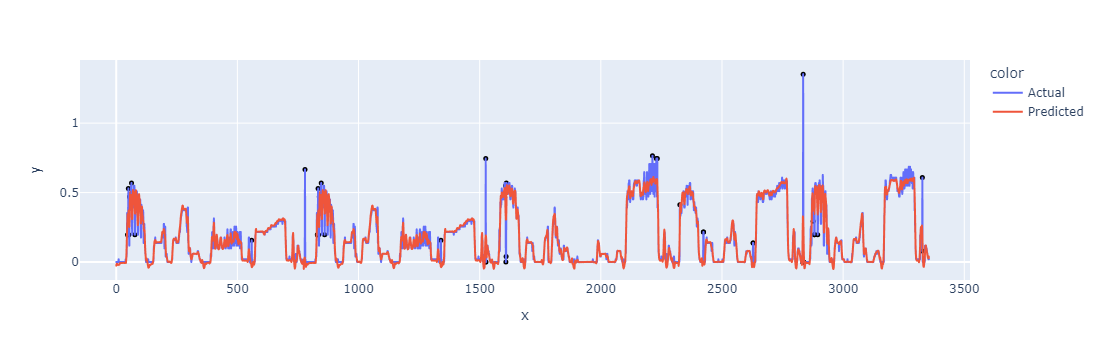

In [ ]:
display_prediction(df20_trainX, predicted_load_train_20, 4, mean, std, 2)

In [ ]:
df_risk_comparision = dfN10_load[dfN10_load['cr'].isin(['CR-3','CR-15'])]
len(df_risk_comparision)

1187

In [ ]:
df_risk_comparision = df_risk_comparision.drop_duplicates(subset=['timestamp'], keep ='first')
df_risk_comparision.reset_index(drop=True)
len(df_risk_comparision)

1187

In [ ]:
df_risk_base = df_risk_comparision[df_risk_comparision['cr'].isin(['CR-3'])]
df_risk_test = df_risk_comparision[df_risk_comparision['cr'].isin(['CR-15'])]

In [ ]:
df_risk_base = df_risk_base[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]
df_risk_test = df_risk_test[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]


In [ ]:

df_risk_base_scaled = data_scaled.transform(df_risk_base)
df_risk_test_scaled = data_scaled.transform(df_risk_test)

print(df_risk_base_scaled.shape, df_risk_test_scaled.shape)

(664, 6) (523, 6)


In [ ]:
df_risk_base_scaled.max()

1.0

In [ ]:
df_risk_test_scaled.max()

0.9929808530963159

In [ ]:
df_risk_base_scaled_x, df_risk_base_scaled_y = to_sequences(df_risk_base_scaled, 10)
print(df_risk_base_scaled_x.shape, df_risk_base_scaled_y.shape)

(654, 10, 6) (654, 6)


In [ ]:
df_risk_test_scaled_x, df_risk_test_scaled_y = to_sequences(df_risk_test_scaled, 10)
print(df_risk_test_scaled_x.shape, df_risk_test_scaled_y.shape)

(513, 10, 6) (513, 6)


In [140]:
def mark_anomalies_current_method_on_production(x, y, t):
    anomalies = []
    count = 0
    for i in range(len(y)):
        if i >= len(x):
            anomalies.append(False)
            # break
        elif y[i, t, 0] > 1.25 * x[i, t, 0] or y[i, t, 0] < 0.75 * x[i, t, 0]:
            anomalies.append(True)
            count += 1
        else:
            anomalies.append(False)
    return np.array(anomalies)


In [141]:
anomalies = mark_anomalies_current_method_on_production(df_risk_base_scaled_x, df_risk_test_scaled_x, 4)
len(anomalies)

NameError: name 'df_risk_base_scaled_x' is not defined

In [142]:
def display_seq(x, y, t):

    anomalies = mark_anomalies_current_method_on_production(x, y, t)
    df1 = pd.DataFrame({'x': range(len(x)), 'y': x[:, t, 0], 'color': 'Baseline', 'anomaly': False})
    df2 = pd.DataFrame({'x': range(len(y)), 'y': y[:, t, 0], 'color': 'New CR', 'anomaly': anomalies})

    df = pd.concat([df1, df2])
    fig = px.line(df, x='x', y='y', color='color')

    df_anomaly = df[df['anomaly']==True]
    print("Number of anomalies: ", len(df_anomaly))
    scatter_data = px.scatter(df_anomaly, x='x', y='y', color_discrete_sequence=['black']).data[0]
    scatter_data.update(marker=dict(size=5))
    fig.add_trace(scatter_data)

    fig.show()


In [143]:
def display_prediction_new(df10_trainX, predicted_load_train, baseline, t, mean, std, relax):
    
    anomaly=mark_anomaly(df10_trainX, predicted_load_train, t, mean, std, relax)
    # print()
    # Create DataFrames for actual and predicted values
    # print(anomaly)
    df1 = pd.DataFrame({'x': range(len(df10_trainX)), 'y': df10_trainX[:, t, 0], 'color': 'Actual Load', 'anomaly': anomaly})
    df2 = pd.DataFrame({'x': range(len(predicted_load_train)), 'y': predicted_load_train[:, t, 0], 'color': 'Predicted Baseline', 'anomaly': False})
    df3 = pd.DataFrame({'x': range(len(baseline)), 'y': baseline[:, t, 0], 'color': 'Old Baseline', 'anomaly':False})
    
    # Concatenate the DataFrames
    df = pd.concat([df1, df2, df3])
    # print(df)
    # Plot both actual and predicted values
    fig = px.line(df, x='x', y='y', color='color')

    df_anomaly = df[df['anomaly']==True]
    print("Number of anomalies: ", len(df_anomaly))
    scatter_data = px.scatter(df_anomaly, x='x', y='y', color_discrete_sequence=['black']).data[0]
    scatter_data.update(marker=dict(size=5))
    fig.add_trace(scatter_data)

    fig.show()


In [144]:
def mark_risk_new(current_load, new_base, t, mean, std, relax):

    tool_disengagement_counter = 0
    tool_overload_counter = 0
    roc_counter = 0

    num_tool_disengagement = 0
    num_tool_overload = 0
    num_roc = 0

    prev_base_load = None
    prev_current_load = None
    for index, (x, y) in enumerate(zip(current_load[:,t,0], new_base[:, t, 0])):
        error = x - y
        # print(error)
        if error > mean + relax*std:
            tool_overload_counter += 1
            if tool_overload_counter > 5:
                # print("new num_tool_overload", index)
                num_tool_overload += 1
                tool_overload_counter = 0
        else:
            tool_overload_counter = 0

        if error < mean - relax*std:
            tool_disengagement_counter += 1
            if tool_disengagement_counter > 5:
                num_tool_disengagement += 1
                tool_disengagement_counter = 0
        else:
            tool_disengagement_counter = 0
        
        if prev_base_load!= None and prev_current_load != None:
            dy = abs(prev_base_load - x)
            dx = abs(prev_current_load - y)
            if dx == 0:
                continue
            slope = dy/dx
            if slope > 2:
                num_roc += 1
                if num_roc >=2 :
                    num_roc = 0
            else:
                num_roc = 0
                
            
        prev_base_load = x
        prev_current_load = y

    data = [
           {'risk_type': 'tool_disengagement', 'risk_count': num_tool_disengagement, 'method': 'New Method'},
           {'risk_type': 'tool_overload', 'risk_count': num_tool_overload, 'method': 'New Method'},
           {'risk_type': 'roc', 'risk_count': num_roc, 'method': 'New Method'},
    ]
    df = pd.DataFrame.from_dict(data)
    return df

In [145]:
def mark_risk_old(current_load, new_base, t):

    tool_disengagement_counter = 0
    tool_overload_counter = 0
    roc_counter = 0

    num_tool_disengagement = 0
    num_tool_overload = 0
    num_roc = 0

    prev_base_load = None
    prev_current_load = None

    for index, (x, y) in enumerate(zip(current_load[:,t,0], new_base[:, t, 0])):
        # error = x - y
        # print(error)
        if x > 1.25*y:
            tool_overload_counter += 1
            if tool_overload_counter > 5:
                # print("num_tool_overload", index, x, y, 1.25*x, .75*x)
                num_tool_overload += 1
                tool_overload_counter = 0
        else:
            tool_overload_counter = 0

        if x < .75*y:
            tool_disengagement_counter += 1
            if tool_disengagement_counter > 5:
                # print("num_tool_diseng", index, x, y, 1.25*x, .75*x)
                num_tool_disengagement += 1
                tool_disengagement_counter = 0
        else:
            tool_disengagement_counter = 0
        
        if prev_base_load!= None and prev_current_load != None:
            dy = abs(prev_base_load - x)
            dx = abs(prev_current_load - y)
            if dx == 0:
                continue
            slope = dy/dx
            
            # print(slope, dy, dx)
            if slope > 2:
                num_roc += 1
                if num_roc >=2 :
                    num_roc = 0
            else:
                num_roc = 0
                
            
        prev_base_load = x
        prev_current_load = y

    # risk = {
    #     'tool_disengagement' : num_tool_disengagement,
    #     'tool_overload': num_tool_overload,
    #     'roc': num_roc,
    #     'method': 'Old Method'
    # }
    # pd.DataFrame.from_dict(risk)
    # return risk
    data = [
           {'risk_type': 'tool_disengagement', 'risk_count': num_tool_disengagement, 'method': 'Old Method'},
           {'risk_type': 'tool_overload', 'risk_count': num_tool_overload, 'method': 'Old Method'},
           {'risk_type': 'roc', 'risk_count': num_roc, 'method': 'Old Method'},
    ]
    df = pd.DataFrame.from_dict(data)
    return df

In [ ]:
# number of risks from current methodology on production

In [146]:
display_seq(df_risk_base_scaled_x, df_risk_test_scaled_x, 4)

NameError: name 'df_risk_base_scaled_x' is not defined

In [ ]:
# risks from new methodology, here red (predicted) line is the basline generated by the model while green line is fixed baseline from current method

In [147]:
df_risk_test_scaled_x_predicted = model.predict(df_risk_test_scaled_x)
display_prediction_new(df_risk_test_scaled_x, df_risk_test_scaled_x_predicted, df_risk_base_scaled_x, 4, mean, std, 2)

NameError: name 'df_risk_test_scaled_x' is not defined

In [ ]:
def classify_anomaly(current_load, new_base, old_base, t, mean, std, relax):
    new_anomalies = mark_risk_new(current_load, new_base, t, mean, std, relax)
    # print(new_anomalies)
    old_anomalies = mark_risk_old(current_load, old_base, t)
    concatenated_df = pd.concat([old_anomalies, new_anomalies])
    
    # Reset the index of the concatenated DataFrame
    concatenated_df.reset_index(drop=True, inplace=True)
    fig = px.bar(concatenated_df, x="method", y="risk_count", color="risk_type", title="risks")
    fig.show()
    
    # print(new_anomalies)
    # print(old_anomalies)

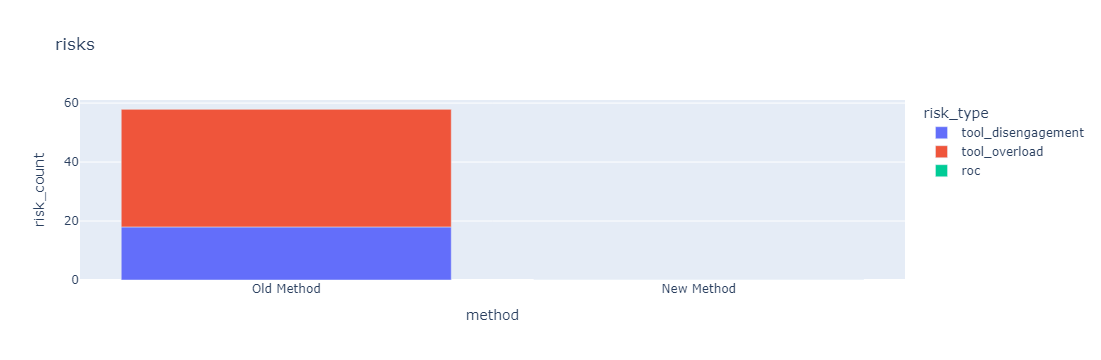

In [ ]:
classify_anomaly(df_risk_test_scaled_x, df_risk_test_scaled_x_predicted, df_risk_base_scaled_x, 4, mean, std, 2)

Number of anomalies:  167


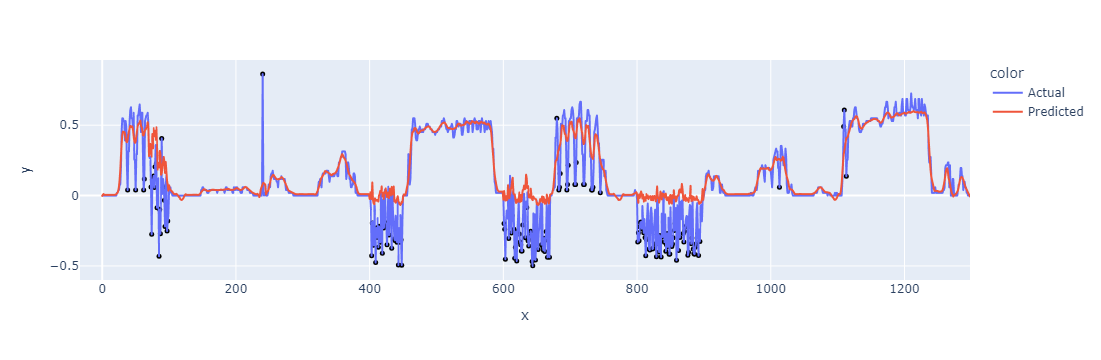

In [ ]:
display_prediction(noise_data, predicted_load_test_noise, 4,  mean, std, 2)

In [148]:
def get_cr_run_current_load_and_baseline(base_cr, current_cr, dfN10_load_filtered_cr):
    basecr = dfN10_load_filtered_cr[dfN10_load_filtered_cr['cr_numeric'].isin([base_cr])]
    current_cr = dfN10_load_filtered_cr[dfN10_load_filtered_cr['cr_numeric'].isin([current_cr])]

    basecr = basecr[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]
    current_cr = current_cr[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]
    
    scaler = MinMaxScaler()
    data_scaled = scaler.fit(basecr)
    # Scaling dataset according to weights of train data
    basecr_scaled = data_scaled.transform(basecr)
    current_cr_scaled = data_scaled.transform(current_cr)
    return basecr_scaled, current_cr_scaled

In [149]:
def plot_new_and_old_risks(base_cr, current_cr, dfN10_load_filtered_cr, relax):
    base, curr = get_cr_run_current_load_and_baseline(base_cr, current_cr, dfN10_load_filtered_cr)
    base_x, base_y = to_sequences(base, 10)
    curr_x, curr_y = to_sequences(curr, 10)
    predicted = model.predict(curr_x)

    display_seq(base_x, curr_x, 4)
    display_prediction_new(curr_x, predicted, base_x, 4, mean, std, relax)
    classify_anomaly(curr_x, predicted, base_x, 4, mean, std, relax)

In [150]:
plot_new_and_old_risks(3, 12, dfN10_load, 2)

KeyError: 'cr_numeric'

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Number of anomalies:  476


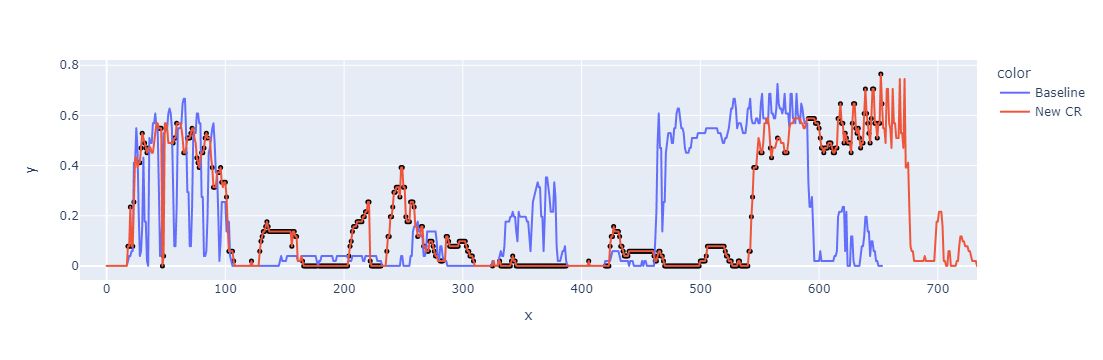

Number of anomalies:  3


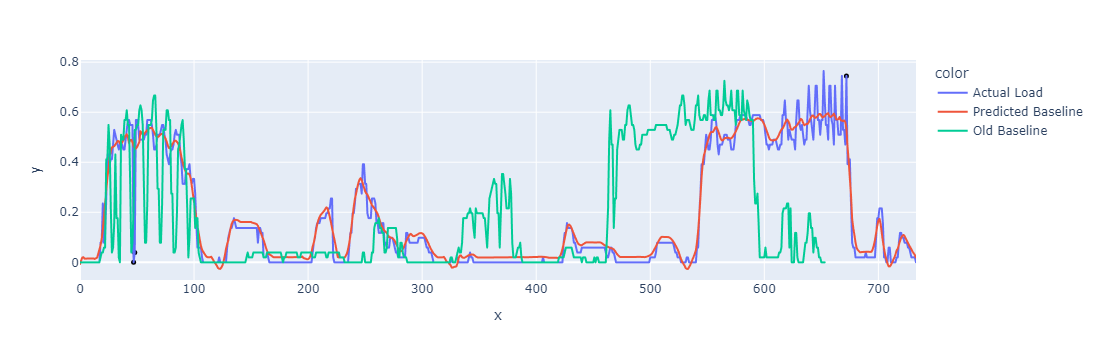

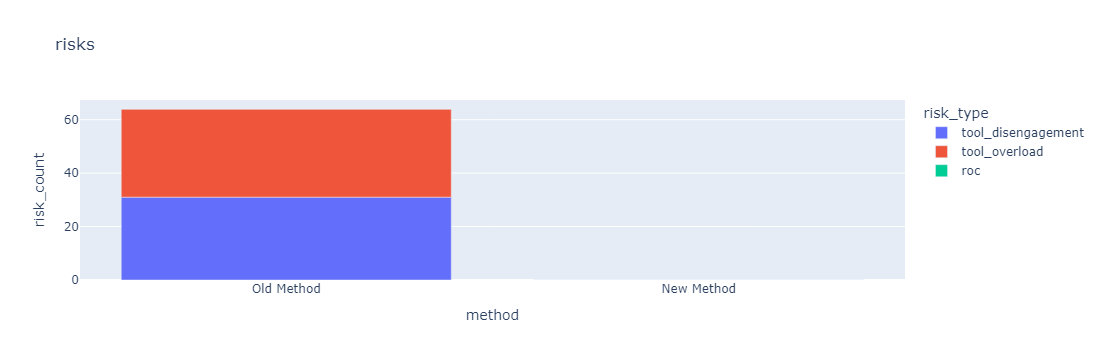

In [ ]:
plot_new_and_old_risks(3, 13, dfN10_load, 2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Number of anomalies:  445


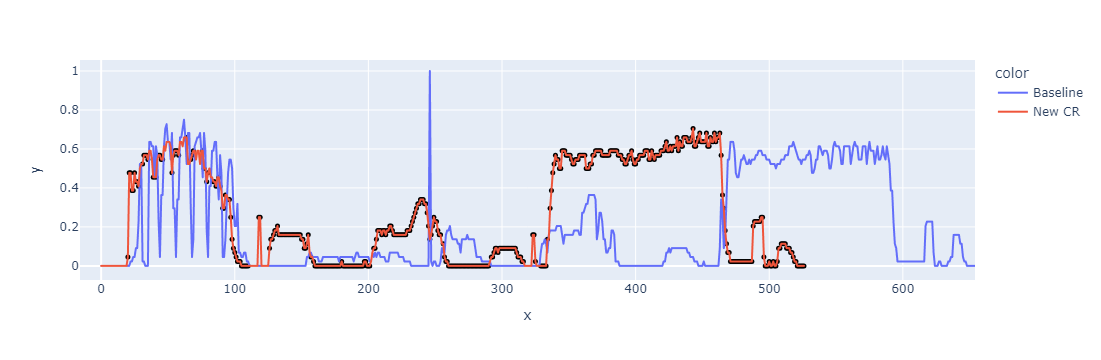

Number of anomalies:  3


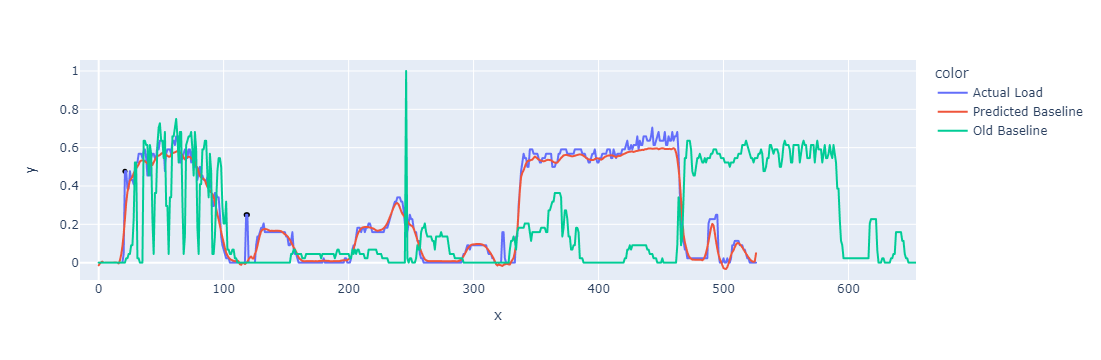

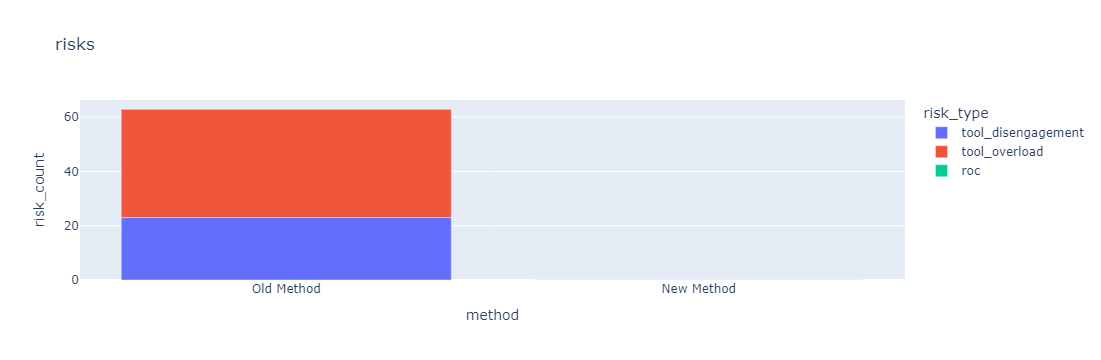

In [ ]:
plot_new_and_old_risks(2, 14, dfN10_load, 2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Number of anomalies:  431


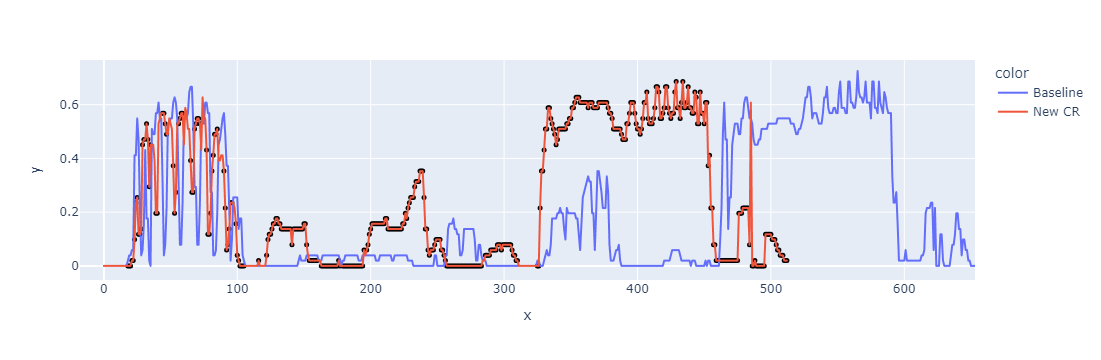

Number of anomalies:  10


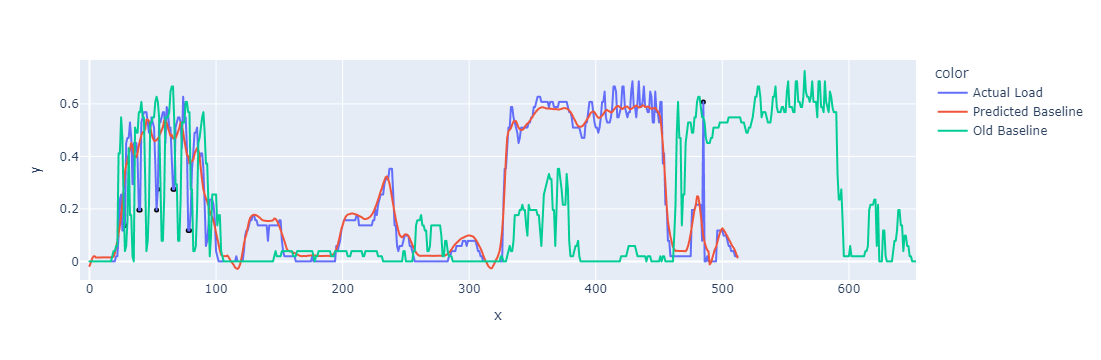

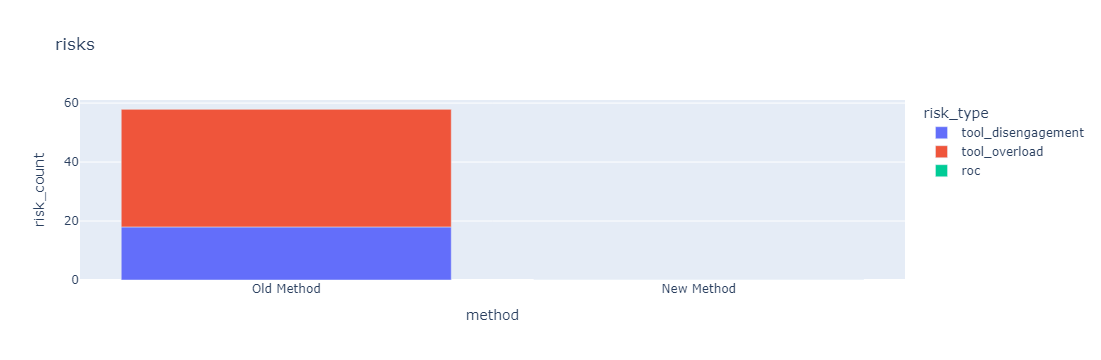

In [ ]:
plot_new_and_old_risks(3, 15, dfN10_load, 2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Number of anomalies:  433


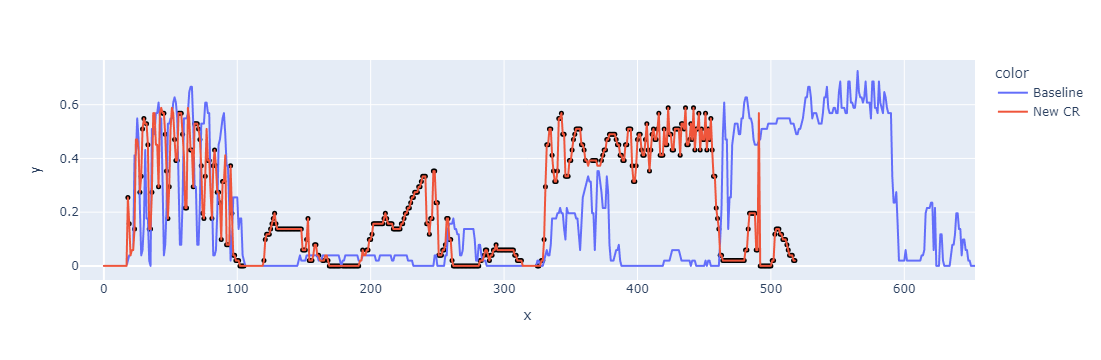

Number of anomalies:  11


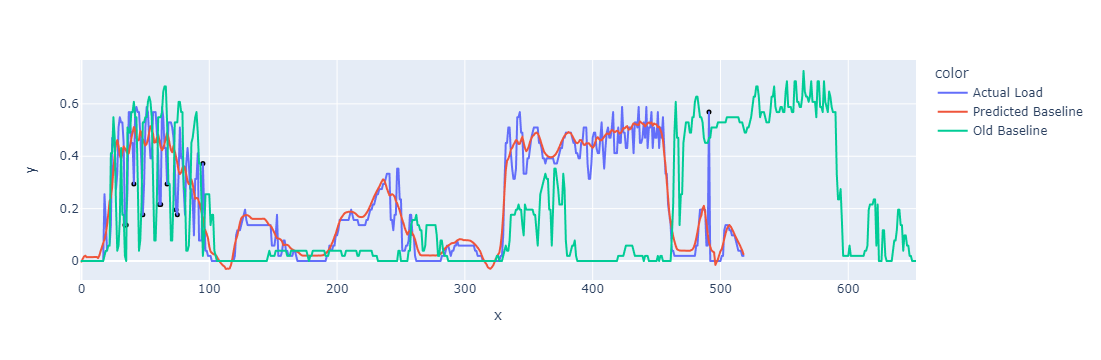

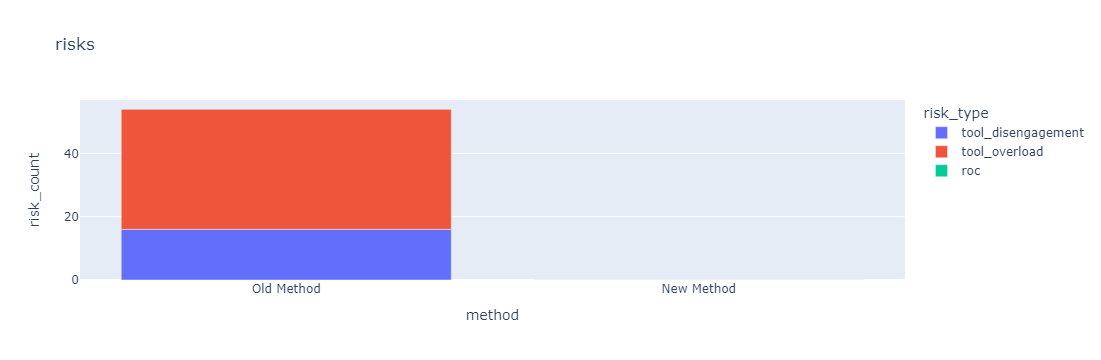

In [ ]:
plot_new_and_old_risks(3, 16, dfN10_load, 2)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Number of anomalies:  433


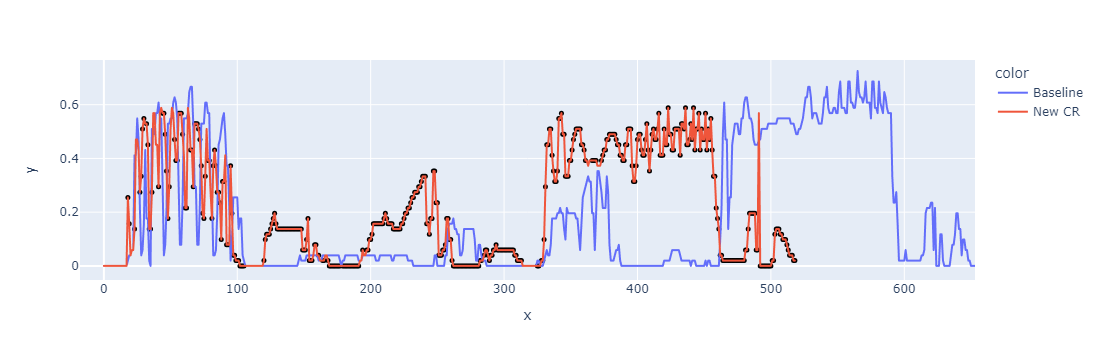

Number of anomalies:  11


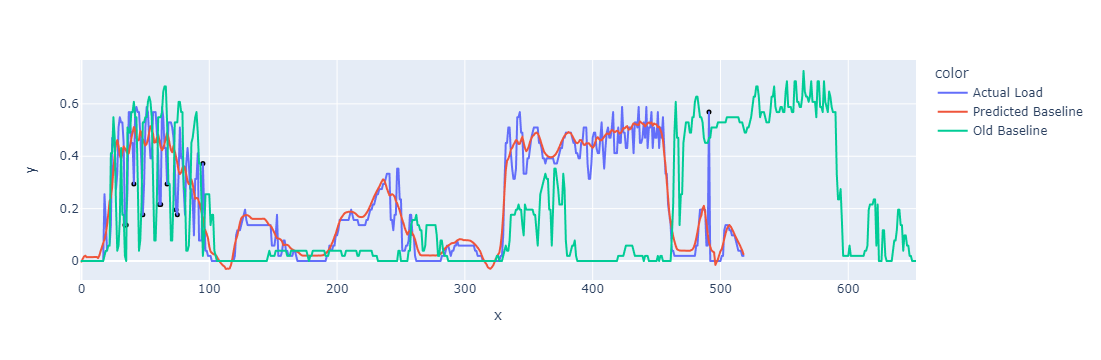

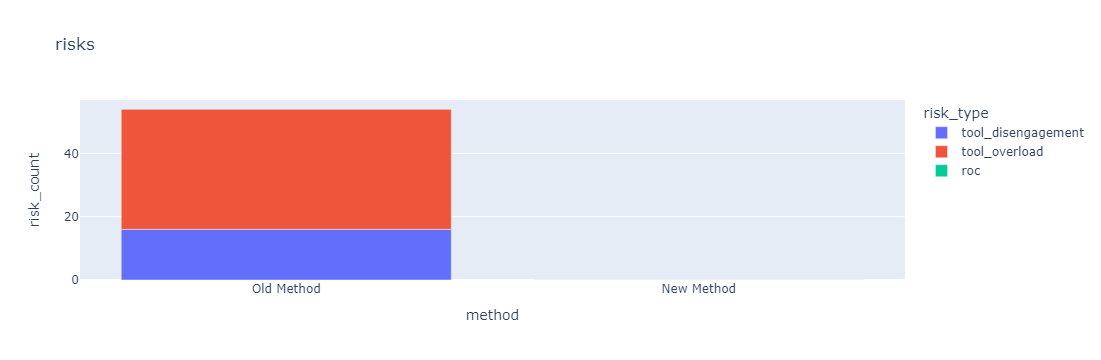

In [ ]:
plot_new_and_old_risks(3, 16, dfN10_load, 2)

In [151]:
#dilation
def plot_new_and_old_risks_for_dilation(base_cr, current_cr, dfN10_load_filtered_cr, prob, dup_count, relax):
    base, curr = get_cr_run_current_load_and_baseline(base_cr, current_cr, dfN10_load_filtered_cr)
    curr = duplicate_rows_with_probability(curr, prob, dup_count)
    base_x, base_y = to_sequences(base, 10)
    curr_x, curr_y = to_sequences(curr, 10)
    predicted = model.predict(curr_x)

    display_seq(base_x, curr_x, 4)
    display_prediction_new(curr_x, predicted, base_x, 4, mean, std, relax)
    classify_anomaly(curr_x, predicted, base_x, 4, mean, std, relax)

In [152]:
plot_new_and_old_risks_for_dilation(3, 12, dfN10_load, 0.1, 5, 2)

KeyError: 'cr_numeric'

In [156]:
def get_data(machines, programs, dates):
    # machines= ['SL40309_015']
    # programs= ['O0005(5303-005-C)']
    # nsequences= ['N1']
    # dates= ['CR1_to_CR4', 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']
    base_name = 'data'
    paths = []
    
    # data_SL40309_015_O0005(5303-005-C)_CR12_to_CR16
    
    for machine in machines:
        for program in programs:
                for date in dates:
                    path = f'{base_name}_{machine}_{program}_{date}.csv'
                    paths.append(path)
    print(paths)
    
    dfs = []
    
    for path in paths:
        data = pd.read_csv(f'../data/{path}')
        dfs.append(data)
        # print(len(data))
        
    data = pd.concat(dfs, ignore_index=True)
    
    data = data.pivot(index=['custom_id', 'timestamp', 'status', 'cr'], columns=['name', 'workstationcomponent'], values='value')
    data = data.reset_index()
    data.columns = [f'{col}_{comp}' if comp != '' else col for col, comp in data.columns]

    split_columns = data['status'].str.split('/', expand=True)
    data[['program_name', 'nsequence', 'execution']] = split_columns[[0,1,2]]
    
    data['load_Rotary_C5'] = data['load_Rotary_C5'].astype(float)
    data['position_Linear_Z'] = data['position_Linear_Z'].astype(float)
    data['position_Linear_X'] = data['position_Linear_X'].astype(float)
    data['spindlespeed_actual_Rotary_C5'] = data['spindlespeed_actual_Rotary_C5'].astype(float)
    data['pathfeedrate_Path_Path_1'] = data['pathfeedrate_Path_Path_1'].astype(float)
    
    data = data.ffill()
    return data

In [ ]:
# machines_diff = ['NL300005_007']
# programs_diff = ['O4073(3980-050-C)']
# dates_diff = ['CR1_to_CR4'] #, 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']
# # data_NL250007_013_O4125(5211-020-D)_N1_cr_1_to_5
# # data_NL300005_007_O4073(3980-050-C)_CR1_to_CR4

# data = get_data(machines_diff, programs_diff, dates_diff)

In [157]:
# raw_data_SL40309_015_O0020(5304-020-F)_N10_2024-03-19

machines_diff = ['SL40309_015']
programs_diff = ['O0020(5304-020-F)']
dates_diff = ['N10_2024-03-19'] #, 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']
# data_NL250007_013_O4125(5211-020-D)_N1_cr_1_to_5
# data_NL300005_007_O4073(3980-050-C)_CR1_to_CR4

data = get_data(machines_diff, programs_diff, dates_diff)

['data_SL40309_015_O0020(5304-020-F)_N10_2024-03-19.csv']


In [158]:
len(data)

25024

In [159]:
def check_model_on_different_program(machines, programs, dates):
    data = get_data(machines_diff, programs_diff, dates_diff)
    data = data[(data['execution'] == 'ACTIVE') & 
            (data['spindlespeed_actual_Rotary_C5'] != 0) & 
            (data['pathfeedrate_Path_Path_1'] != 0) & 
            (data['load_Rotary_C5'] > 0) & 
            (data['pathfeedrate_Path_Path_1'] <= 1000)]
    
    # data_c = data[data['program_name'].isin(['O4125(5211-020-D)'])]
    # dfN10 = data_c[data_c['nsequence'].isin(['N1'])]
    data.dropna(subset=['load_Rotary_C5'],inplace=True)
    
    df_diff = data[['timestamp', 'load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution', 'program_name', 'nsequence', 'cr']]
    df_diff = df_diff.drop_duplicates(subset=['timestamp'], keep ='first')
    df_diff.reset_index(drop=True)

    df_diff['index'] = df_diff.groupby(['cr']).cumcount()
    
    fig = px.line(df_diff, x="index", y="load_Rotary_C5", color='cr')
    fig.update_layout(title_text="Load Vs Index")
    fig.show()

    df_diff['execution'] = LE.fit_transform(df_diff['execution'])
    df_diff.fillna(0, inplace=True)

    df_diff[['load_Rotary_C5']]= scaler1.fit_transform(df_diff[['load_Rotary_C5']])

    df_diff = df_diff[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]

    # scalar = MinMaxScaler()
    # data_scaled = scaler.fit(df_diff)
    # df_diff_scaled = data_scaled.transform(df_diff)
    df_diff_scaled = data_scaled.transform(df_diff)
    print(f"Max Before {df_diff.max()}")
    print(f"Max After {df_diff_scaled.max()}")
    # df_diff_scaled[-3]
    df10_trainX_diff, df10_trainY_diff = to_sequences(df_diff_scaled, 10)
    predicted_diff = model.predict(df10_trainX_diff)
    # print(predicted_diff[0:10])
    display_prediction(df10_trainX_diff, predicted_diff, 4, mean, std, 2)
    


In [160]:
machines_diff = ['SL40309_015']
programs_diff = ['O0020(5304-020-F)']
dates_diff = ['N10_2024-03-19'] #, 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']
check_model_on_different_program(machines_diff, programs_diff, dates_diff)

['data_SL40309_015_O0020(5304-020-F)_N10_2024-03-19.csv']


Max Before load_Rotary_C5                     1.0000
position_Linear_X                 24.8753
position_Linear_Z                 17.7050
spindlespeed_actual_Rotary_C5     57.0000
pathfeedrate_Path_Path_1         259.5800
execution                          0.0000
dtype: float64
Max After 1.2516257125810348
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Number of anomalies:  0


In [161]:
machines_diff = ['NL250007_013']
programs_diff = ['O4125(5211-020-D)']
# data_SL40309_015_O0005(5303-005-C)_CR1_to_CR4
# data_NL250007_013_O4125(5211-020-D)_N1_cr_1_to_5
dates_diff = ['N1_cr_1_to_5']
check_model_on_different_program(machines_diff, programs_diff, dates_diff)

['data_NL250007_013_O4125(5211-020-D)_N1_cr_1_to_5.csv']


Max Before load_Rotary_C5                     1.00000
position_Linear_X                453.49922
position_Linear_Z                320.95440
spindlespeed_actual_Rotary_C5     73.00000
pathfeedrate_Path_Path_1         629.00000
execution                          0.00000
dtype: float64
Max After 22.741812274694034
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Number of anomalies:  3412


In [168]:
machines_diff = ['SL40309_015']
programs_diff = ['O0020(5304-020-F)']
dates_diff = ['N10_2024-03-19'] #, 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']

# machines_diff = ['SL40309_015']
# programs_diff = ['O0005(5303-005-C)']
# # data_SL40309_015_O0005(5303-005-C)_CR1_to_CR4
# dates_diff = ['CR1_to_CR4', 'CR5_to_CR8', 'CR9_to_CR12', 'CR12_to_CR16']

data = get_data(machines_diff, programs_diff, dates_diff)
data = data[(data['execution'] == 'ACTIVE') & 
        (data['spindlespeed_actual_Rotary_C5'] != 0) & 
        (data['pathfeedrate_Path_Path_1'] != 0) & 
        (data['load_Rotary_C5'] > 0) & 
        (data['pathfeedrate_Path_Path_1'] <= 1000)]

# data_c = data[data['program_name'].isin(['O4125(5211-020-D)'])]
# dfN10 = data_c[data_c['nsequence'].isin(['N1'])]
data.dropna(subset=['load_Rotary_C5'],inplace=True)

df_diff = data[['timestamp', 'load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution', 'program_name', 'nsequence', 'cr']]
df_diff = df_diff.drop_duplicates(subset=['timestamp'], keep ='first')
df_diff.reset_index(drop=True)

df_diff['index'] = df_diff.groupby(['cr']).cumcount()

df_diff['execution'] = LE.fit_transform(df_diff['execution'])
df_diff.fillna(0, inplace=True)
# scaler1 = MinMaxScaler()

# df_diff[['load_Rotary_C5']]= scaler2.fit_transform(df_diff[['load_Rotary_C5']])
df_diff = df_diff[['load_Rotary_C5', 'position_Linear_X', 'position_Linear_Z', 'spindlespeed_actual_Rotary_C5', 'pathfeedrate_Path_Path_1', 'execution',]]

# scalar = MinMaxScaler()
# data_scaled = scaler.fit(df_diff)
df_diff_scaled = scaler2.transform(df_diff)


['data_SL40309_015_O0020(5304-020-F)_N10_2024-03-19.csv']


In [169]:
df_diff_scaled.max()

np.float64(1.2516257125810348)

In [170]:
df_diff_scaled

array([[ 2.74509804e-01,  1.02633730e+00,  1.07283146e+00,
         7.65550239e-02,  1.06574739e+00,  0.00000000e+00],
       [ 3.92156863e-02,  7.60693103e-01,  8.31153613e-01,
         7.65550239e-02,  1.06574739e+00,  0.00000000e+00],
       [ 3.92156863e-02,  7.60693103e-01,  5.46059041e-01,
         7.89473684e-02,  1.06566433e+00,  0.00000000e+00],
       ...,
       [ 3.92156863e-02,  7.22984593e-01,  2.56378325e-01,
         5.98086124e-02, -8.30668273e-05,  0.00000000e+00],
       [ 1.96078431e-02,  7.22508285e-01,  3.01931879e-01,
         5.02392344e-02,  7.80329775e-01,  0.00000000e+00],
       [ 1.96078431e-02,  7.64684058e-01,  5.81236329e-01,
         4.78468900e-02,  9.83428168e-01,  0.00000000e+00]],
      shape=(3482, 6))

In [171]:
df_diff

,load_Rotary_C5,position_Linear_X,position_Linear_Z,spindlespeed_actual_Rotary_C5,pathfeedrate_Path_Path_1,execution
18,15.0,20.3819,17.7050,45.0,256.83,0
23,3.0,15.0836,12.4458,45.0,256.83,0
29,3.0,15.0836,6.2418,46.0,256.81,0
88,3.0,11.4611,2.0000,46.0,236.20,0
93,3.0,11.4611,-0.0620,46.0,236.20,0
...,...,...,...,...,...,...
24773,3.0,14.3431,-0.0620,38.0,0.21,0
24775,3.0,14.3315,-0.0620,38.0,0.21,0
24776,3.0,14.3315,-0.0620,38.0,0.21,0
24987,2.0,14.3220,0.9293,34.0,188.11,0


In [172]:
df_diff.max()

load_Rotary_C5                    43.0000
position_Linear_X                 24.8753
position_Linear_Z                 17.7050
spindlespeed_actual_Rotary_C5     57.0000
pathfeedrate_Path_Path_1         259.5800
execution                          0.0000
dtype: float64

In [173]:
df10_trainX_diff, df10_trainY_diff = to_sequences(df_diff_scaled, 10)
predicted_diff = model.predict(df10_trainX_diff)
display_prediction(df10_trainX_diff, predicted_diff, 4, mean, std, 2)

109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Number of anomalies:  13
